In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
## reading words
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [6]:
## creating characters vocabulary
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [75]:
# building dataset using first three letter to predict the next one
block_size = 3 # window of letter (context)
x = [] # store context (three letter in a word)
y = [] # what needs to predict for the respective context in x

for w in words:
    # print(w)

    context = [0] * block_size
    for ch in w + '.':
        index = stoi[ch]
        y.append(index)
        x.append(context)
        # print(''.join(itos[i] for i in context), '--->' , ch)
        context = context[1:] + [index]

X = torch.tensor(x)
Y = torch.tensor(y)

## Creating separate training, dev/validate , test dataset

In [99]:
# build the dataset

def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y= [], []
    for w in words: 

        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print("'.join(itos[i] for i in context), '->', itos[ix])
            context = context[1:] + [ix] # crop and append

    X = torch. tensor(X)
    Y = torch. tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random. seed(42)
random. shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [15]:
print(X)

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])


In [20]:
## creating embedding
C = torch.randn([27,2])
C

tensor([[ 0.5064, -1.3704],
        [ 0.6881, -0.6521],
        [ 0.1260,  0.3268],
        [ 2.0410,  0.0801],
        [ 1.9736,  0.1635],
        [-2.0576, -0.1430],
        [ 0.2727,  1.6183],
        [-0.7998, -0.5262],
        [-0.3578,  1.4745],
        [-0.7888,  1.2930],
        [ 1.9051,  0.2151],
        [ 1.2265, -0.8286],
        [ 1.2552,  0.0489],
        [ 0.6323,  0.7551],
        [-1.4094,  1.1843],
        [ 0.8316, -0.2145],
        [-0.4503, -1.2339],
        [ 0.3989, -0.2916],
        [-0.6238, -0.6531],
        [ 2.2835, -1.4589],
        [ 1.5304,  0.7866],
        [-1.1244,  0.2850],
        [ 0.2235,  2.1257],
        [-0.7340, -1.4179],
        [-0.3842, -0.2913],
        [ 0.0430,  1.0282],
        [ 0.6328, -1.3827]])

In [21]:
emb = C[X]
emb

tensor([[[ 0.5064, -1.3704],
         [ 0.5064, -1.3704],
         [ 0.5064, -1.3704]],

        [[ 0.5064, -1.3704],
         [ 0.5064, -1.3704],
         [-2.0576, -0.1430]],

        [[ 0.5064, -1.3704],
         [-2.0576, -0.1430],
         [ 0.6323,  0.7551]],

        [[-2.0576, -0.1430],
         [ 0.6323,  0.7551],
         [ 0.6323,  0.7551]],

        [[ 0.6323,  0.7551],
         [ 0.6323,  0.7551],
         [ 0.6881, -0.6521]],

        [[ 0.5064, -1.3704],
         [ 0.5064, -1.3704],
         [ 0.5064, -1.3704]],

        [[ 0.5064, -1.3704],
         [ 0.5064, -1.3704],
         [ 0.8316, -0.2145]],

        [[ 0.5064, -1.3704],
         [ 0.8316, -0.2145],
         [ 1.2552,  0.0489]],

        [[ 0.8316, -0.2145],
         [ 1.2552,  0.0489],
         [-0.7888,  1.2930]],

        [[ 1.2552,  0.0489],
         [-0.7888,  1.2930],
         [ 0.2235,  2.1257]],

        [[-0.7888,  1.2930],
         [ 0.2235,  2.1257],
         [-0.7888,  1.2930]],

        [[ 0.2235,  2

In [22]:
w1 = torch.randn([6,100])
b = torch.randn(100)

In [32]:
# torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],1) not scaleable
# torch.cat(torch.unbind(emb,1),1).shape
# more efficient way
# emb.view([32,6])
h = torch.tanh(emb.view([-1,6]) @ w1 + b)
h

tensor([[ 0.9951,  0.9997, -1.0000,  ...,  0.9385,  0.2037,  0.1627],
        [-0.9911,  1.0000, -0.9688,  ..., -0.4093,  0.8852,  0.9999],
        [ 0.9999,  0.7003, -0.9993,  ...,  0.9851, -0.7678,  0.9367],
        ...,
        [ 0.9984,  0.9880, -0.9183,  ..., -0.1444, -0.9761,  0.9995],
        [-0.3602,  0.8326,  0.9462,  ...,  0.7863, -0.6905,  0.9974],
        [ 0.2154, -1.0000,  0.9522,  ...,  0.1351,  0.4006, -0.7183]])

In [33]:
w2 = torch.randn([100,27])
b2 = torch.randn(27)

In [34]:
logits = (h @ w2) + b2

In [35]:
logits

tensor([[-1.7642e+01, -3.1810e+00,  1.8694e+00,  2.0665e+00,  1.9328e+01,
          3.9795e+00,  3.4396e+01, -1.2837e+01, -9.1979e-01, -1.7713e-01,
         -2.1042e+01, -1.2799e+00,  2.3170e+00, -1.1095e+01, -1.7569e+00,
         -8.6076e+00,  4.1152e+00,  9.2388e-01, -5.9609e+00, -1.2347e+00,
         -2.3463e+00, -1.1665e+00, -6.3583e+00, -8.3762e-01, -9.2386e+00,
          6.5162e-02, -1.5309e+00],
        [-7.6610e+00,  1.0581e+01,  1.0277e+00, -2.2032e+01,  1.2410e+01,
         -3.4262e+00,  2.5068e+01, -1.1542e+01,  9.1251e-01, -1.6792e+01,
         -1.2280e+01,  1.1399e+00, -4.1391e+00, -1.4810e+01,  7.5671e+00,
         -1.3266e+01, -1.4996e+00,  1.0388e+01, -7.2657e+00,  1.6718e+00,
         -1.4284e+00,  1.0928e+00,  1.4428e+01,  2.1064e+00, -4.5124e+00,
          3.5357e+00, -1.1303e+01],
        [ 8.4252e+00, -8.2354e+00,  1.2028e+01,  1.0717e+01,  9.8019e-01,
         -2.1328e-01,  1.0454e+01, -1.4481e+00, -1.3192e+01,  4.1492e-01,
         -1.8320e+01,  3.5633e+00,  1.05

In [40]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)


In [43]:
loss = -prob[torch.arange(32),Y].log().mean()

In [44]:
loss

tensor(26.2573)

In [121]:
## Same code but more better structured 
g = torch.Generator().manual_seed(2147483647)
C = torch.randn([27,10])
emb = C[Xtr]
w1 = torch.randn([30,200])
b1 = torch.randn(200)
w2 = torch.randn([200,27])
b2 = torch.randn(27)
parameters = [C,w1,b1,w2,b2]

In [122]:
sum(p.nelement() for p in parameters)

11897

In [123]:
for p in parameters:
    p.requires_grad = True

In [88]:
## Finder better learning rate
lre = torch.linspace(-3,0,1000)
lre = 10**lre
lre

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [124]:
lri = []
lossi = []
stepi = []

In [133]:

for i in range(30000):
    ## creating mini batchs
    ix = torch.randint(0,Xtr.shape[0],(32,))
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view([-1,30]) @ w1 + b1)
    logits = h @ w2 + b2
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdim=True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    # more efficient way
    loss = F.cross_entropy(logits,Ytr[ix])
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    lr = 0.05
    for p in parameters:
        p.data += -lr * p.grad
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
print(loss.item())

2.138598680496216


In [134]:
## evaluate in dev
emb = C[Xdev]
h = torch.tanh(emb.view([-1,30]) @ w1 + b1)
logits = h @ w2 + b2
loss = F.cross_entropy(logits,Ydev)
loss

tensor(2.3431, grad_fn=<NllLossBackward0>)

# As Dev's  loss and training data loss is same mean our model is underfitting, because our parameters are very low now we will increse the params to see the improvement

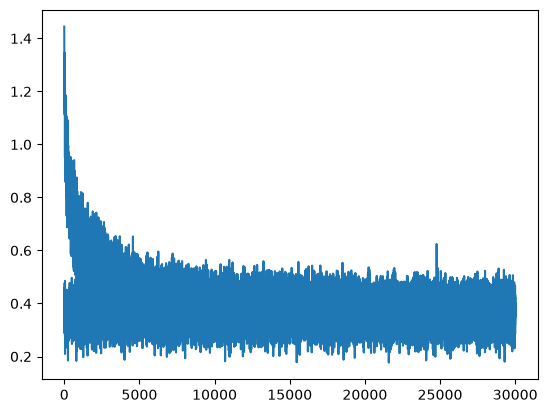

In [130]:
# plt.plot(lri,lossi)/
plt.plot(stepi,lossi)

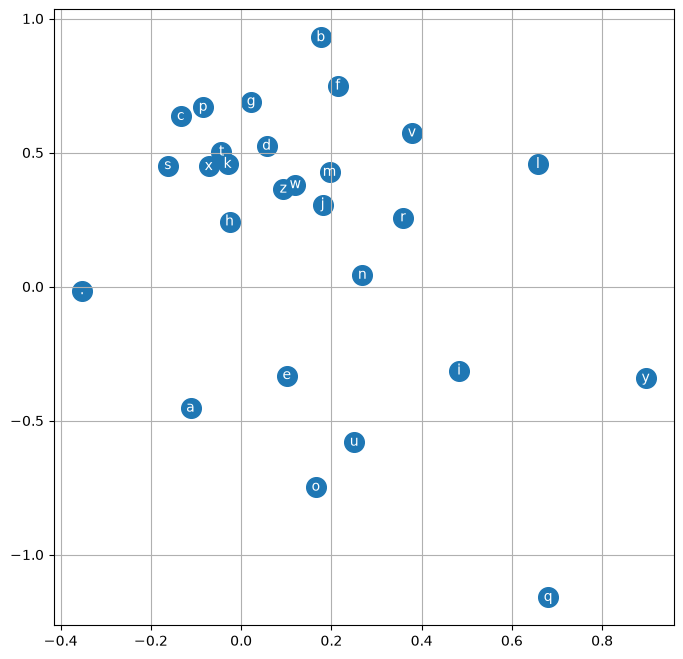

In [120]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
    plt.grid('minor')

In [140]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):

    out= []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1,block_size,d)
        h = torch.tanh(emb.view(1, -1) @ w1 + b1)
        logits = h @ w2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context [1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

print(''.join(itos[i] for i in out))

emme.
